# **Kernel Methods and Regularization:** Applied ML Exercise

## 1. Objective

This project explores two fundamental concepts in machine learning:
1. **Kernel Methods using Support Vector Machines (SVM)**
2. **Regularization techniques for feature selection and overfitting prevention**

The goal is to understand and apply these techniques on real-world datasets, focusing on classification tasks and model generalization.

## 2. Research Questions

- How do **polynomial kernels** and **radial basis function (RBF) kernels** affect classification performance in SVM?
- How can hyperparameters (e.g., **C**, **gamma**, **degree**) be optimized to maximize performance metrics such as **F1 Score** or **Recall**?
- How does **regularization (L1, L2, ElasticNet)** help identify key features and mitigate overfitting?
- Which **visualization techniques** can help interpret feature importance and correlations effectively?

## 3. Dataset

- A publicly available classification dataset was selected from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php), ensuring it is **not based on cancer or wine data**.
- The dataset was preprocessed for feature scaling and class balance, where necessary.

## 4. Technical Highlights

- **SVM with Polynomial and RBF Kernels** implemented using `scikit-learn`
- **Hyperparameter Optimization** using **Grid Search** and metric-driven selection (e.g., **F1 Score** and **Recall**)
- **Regularization** explored through Ridge, Lasso, and ElasticNet applied to an additional dataset
- **Visualization** of:
  - Decision boundaries
  - Feature importance
  - Feature correlation heatmaps

All code was developed in **Python (Jupyter Notebook)**, making use of **scikit-learn, matplotlib, seaborn, pandas, and numpy**.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.linear_model import LassoCV, ElasticNetCV, RidgeCV, Lasso, ElasticNet, Ridge, LinearRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score, recall_score, precision_score
from sklearn.metrics import accuracy_score, classification_report, f1_score, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# **Part 1. Kernel Trick in Flight Cancellations**
*   <u>Dataset:</u> Kaggle Flight Cancellation Dataset
*   <u>Models:</u> Nonlinear kernel classification using Support Vector Machines (SVM) with Polynomial and Gaussian Radial Basis Function (RBF)
*   <u>Objective:</u> Evaluate the performance of these kernels on a classification task with different metrics and determine which combination of hyperparameters maximizes each of the scores

## Step 1.1: Download the dataset

We use a flight cancellation dataset, which contains information about various flights, including departure and arrival delays, airline carrier, weather conditions, and whether a flight was eventually canceled. The classification task is to **predict whether a specific flight will be canceled based on these features**.

In [2]:
# Download dataset
import kagglehub
path = kagglehub.dataset_download("patrickzel/flight-delay-and-cancellation-dataset-2019-2023")
csv_file = os.path.join(path, "flights_sample_3m.csv")
df = pd.read_csv(csv_file, nrows=100000)
pd.set_option('display.max_columns', None)
print(df.shape)

(100000, 32)


## Step 1.2: Preprocess the Data

In [3]:
# Data cleaning
missing_ratio = df.isna().mean().sort_values(ascending=False)
useful_cols = missing_ratio[missing_ratio < 0.5].index.tolist()
df = df[useful_cols]
print(df.shape)
display(df.head(3))

(100000, 26)


,AIR_TIME,ELAPSED_TIME,ARR_DELAY,WHEELS_ON,ARR_TIME,TAXI_IN,WHEELS_OFF,TAXI_OUT,DEP_DELAY,DEP_TIME,CRS_ELAPSED_TIME,ORIGIN_CITY,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,DISTANCE,ORIGIN,DIVERTED,DEST,CANCELLED,DEST_CITY,CRS_DEP_TIME,CRS_ARR_TIME,AIRLINE,FL_DATE
0,153.0,176.0,-14.0,1443.0,1447.0,4.0,1210.0,19.0,-4.0,1151.0,186.0,"Fort Lauderdale, FL",United Air Lines Inc.: UA,UA,19977,1562,1065.0,FLL,0.0,EWR,0.0,"Newark, NJ",1155,1501,United Air Lines Inc.,2019-01-09
1,189.0,236.0,-5.0,2232.0,2310.0,38.0,2123.0,9.0,-6.0,2114.0,235.0,"Minneapolis, MN",Delta Air Lines Inc.: DL,DL,19790,1149,1399.0,MSP,0.0,SEA,0.0,"Seattle, WA",2120,2315,Delta Air Lines Inc.,2022-11-19
2,87.0,112.0,0.0,1247.0,1252.0,5.0,1020.0,20.0,6.0,1000.0,118.0,"Denver, CO",United Air Lines Inc.: UA,UA,19977,459,680.0,DEN,0.0,MSP,0.0,"Minneapolis, MN",954,1252,United Air Lines Inc.,2022-07-22


We transform the datatype and structure for modeling preparation. Moreover, for the variables with few missing values, we use median or mode (the most frequent one) to fill it.

In [4]:
# Preprocessing
df = df[df['CANCELLED'].isin([0, 1])]
df['CANCELLED'] = df['CANCELLED'].astype(int)

cancelled = df[df['CANCELLED'] == 1]
not_cancelled = df[df['CANCELLED'] == 0]
m = min(len(cancelled), len(not_cancelled))
df_balanced = pd.concat([
    cancelled.sample(n=m, random_state=42),
    not_cancelled.sample(n=m, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced class distribution:")
print(df_balanced['CANCELLED'].value_counts())

# Feature separation
y = df_balanced['CANCELLED']
X = df_balanced.drop(columns=['CANCELLED'])
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Pipelines to deal with missing values and standardize the data
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

Balanced class distribution:
CANCELLED
0    2596
1    2596
Name: count, dtype: int64


## Step 1.3 : Model with SVC
We build a classification model using SVM with a polynomial or RBF kernel. GridSearch is used to explore different combinations of hyperparameters.

In [5]:
# Define a function to evaluate the SVC model so we can reuse it for both polynomial and rbf kernel
def evaluate_svc_model(X_train, X_test, y_train, y_test, kernel, param_grid, hue_param):
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', SVC())
    ])

    grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1', return_train_score=True)
    grid.fit(X_train, y_train)

    print("Best Params:", grid.best_params_)
    y_pred = grid.predict(X_test)
    print("Test F1 Score:", f1_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    results = pd.DataFrame(grid.cv_results_)
    metrics_df = results.rename(columns={
        f'param_classifier__C': 'C',
        f'param_classifier__{hue_param}': hue_param,
        'mean_train_score': 'train_f1',
        'mean_test_score': 'cv_f1',
        'mean_fit_time': 'train_time_sec'
    })[['C', hue_param, 'train_f1', 'cv_f1', 'train_time_sec']]

    for i, row in metrics_df.iterrows():
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', SVC(kernel=kernel, C=row['C'], **{hue_param: row[hue_param]}))
        ])
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        metrics_df.loc[i, 'test_f1'] = f1_score(y_test, y_pred)
        metrics_df.loc[i, 'test_acc'] = accuracy_score(y_test, y_pred)
        metrics_df.loc[i, 'test_recall'] = recall_score(y_test, y_pred)
        metrics_df.loc[i, 'test_precision'] = precision_score(y_test, y_pred)

    return metrics_df

def plot_metric(df, train_col, test_col, title, ylabel, hue, ylim=(0.5, 1.0), palette='deep'):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.lineplot(ax=axes[0], data=df, x='C', y=train_col, hue=hue, marker='o', palette=palette)
    axes[0].set_title(f"Train {title}")
    axes[0].set_ylabel(ylabel)
    axes[0].set_ylim(ylim)
    axes[0].grid(True)

    sns.lineplot(ax=axes[1], data=df, x='C', y=test_col, hue=hue, marker='o',palette=palette)
    axes[1].set_title(f"Test {title}")
    axes[1].set_ylabel(ylabel)
    axes[1].set_ylim(ylim)
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()

### 1. Polynomial Kernel:


In [6]:
# Polynomial Kernel Evaluation
poly_params = {
    'classifier__kernel': ['poly'],
    'classifier__C': [0.1, 0.5, 1, 3, 5, 7],
    'classifier__degree': [1, 2, 3, 4, 5, 6, 7]
}
poly_metrics_df = evaluate_svc_model(X_train, X_test, y_train, y_test, 'poly', poly_params, 'degree')

Best Params: {'classifier__C': 7, 'classifier__degree': 2, 'classifier__kernel': 'poly'}
Test F1 Score: 0.980367321089297
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       779
           1       0.97      0.99      0.98       779

    accuracy                           0.98      1558
   macro avg       0.98      0.98      0.98      1558
weighted avg       0.98      0.98      0.98      1558



According to GridSearchCV, the best parameter combination based on the F1 score is C = 7 and degree = 2 using a polynomial kernel. Since our primary goal is to identify all cancelled flights (class 1), we are particularly interested in the recall metric. 
- The results show that the recall for cancelled flights is approximately 0.99, meaning that we have successfully identified almost all cancelled flights. In addition, a precision rate of around 0.97 indicates that the rate of false alarms is relatively low.

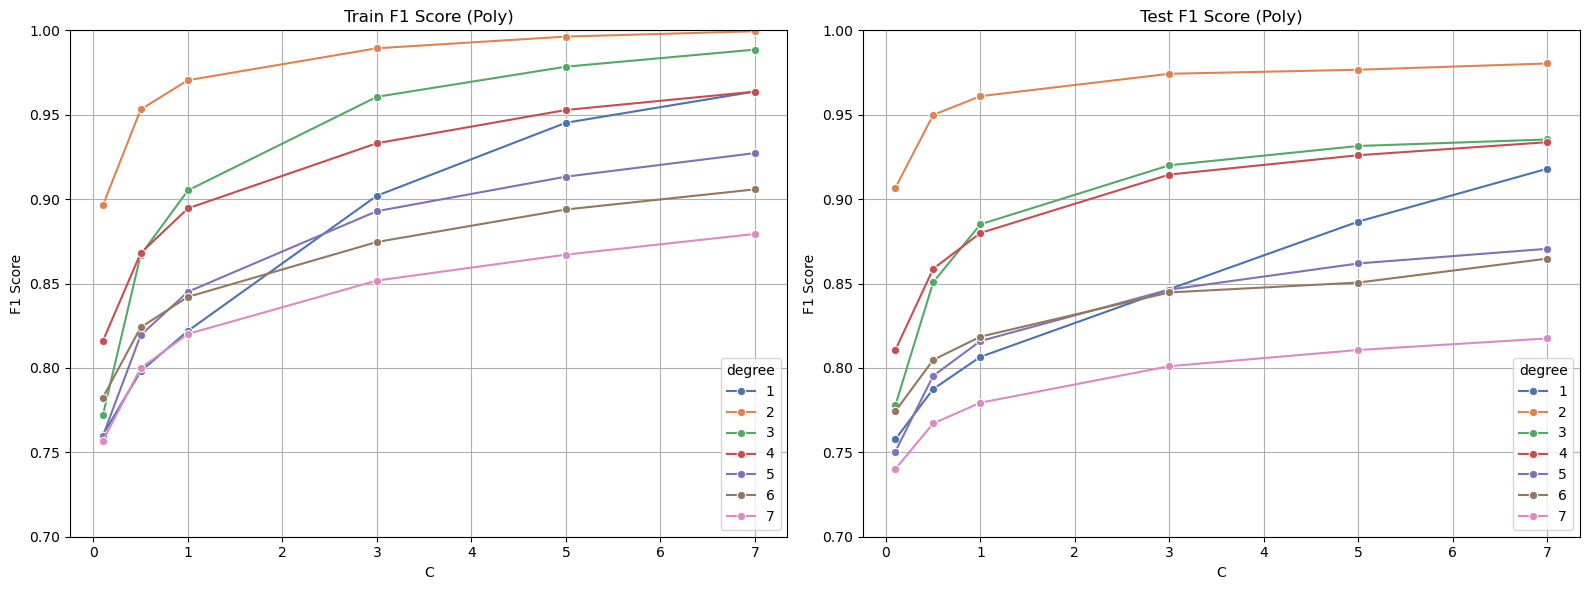

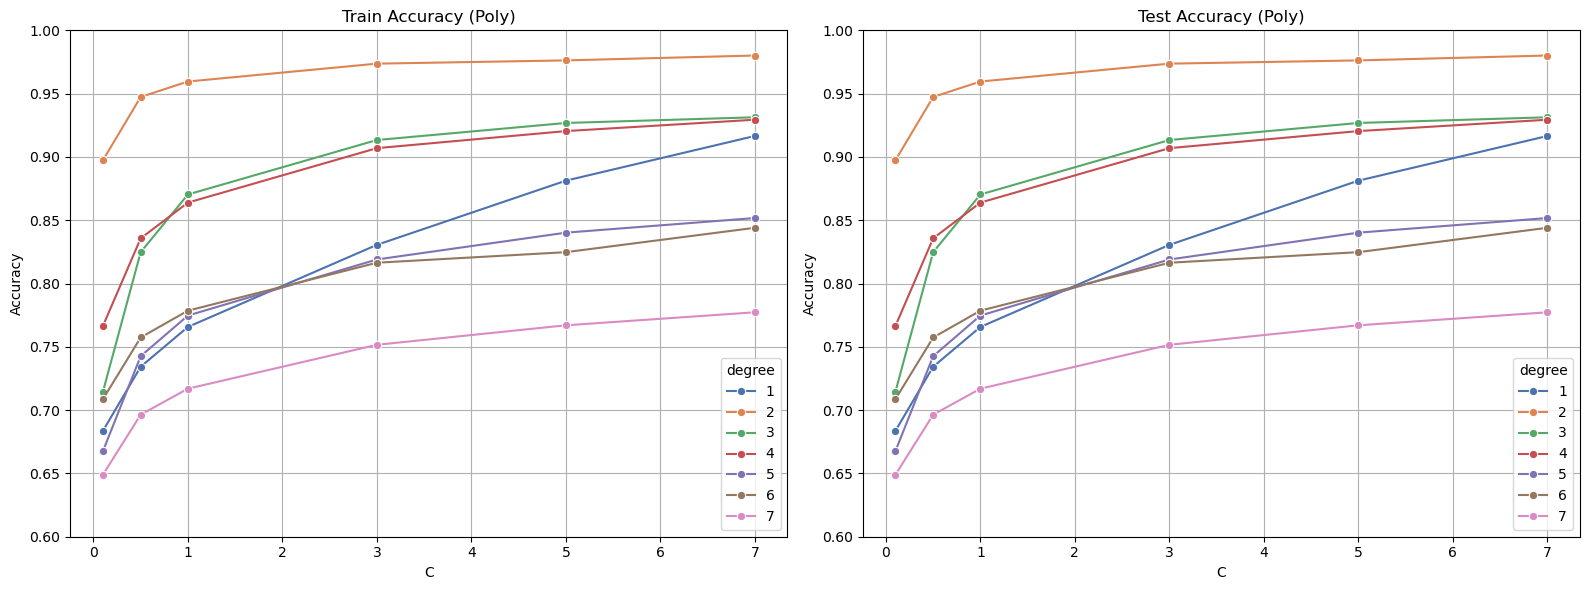

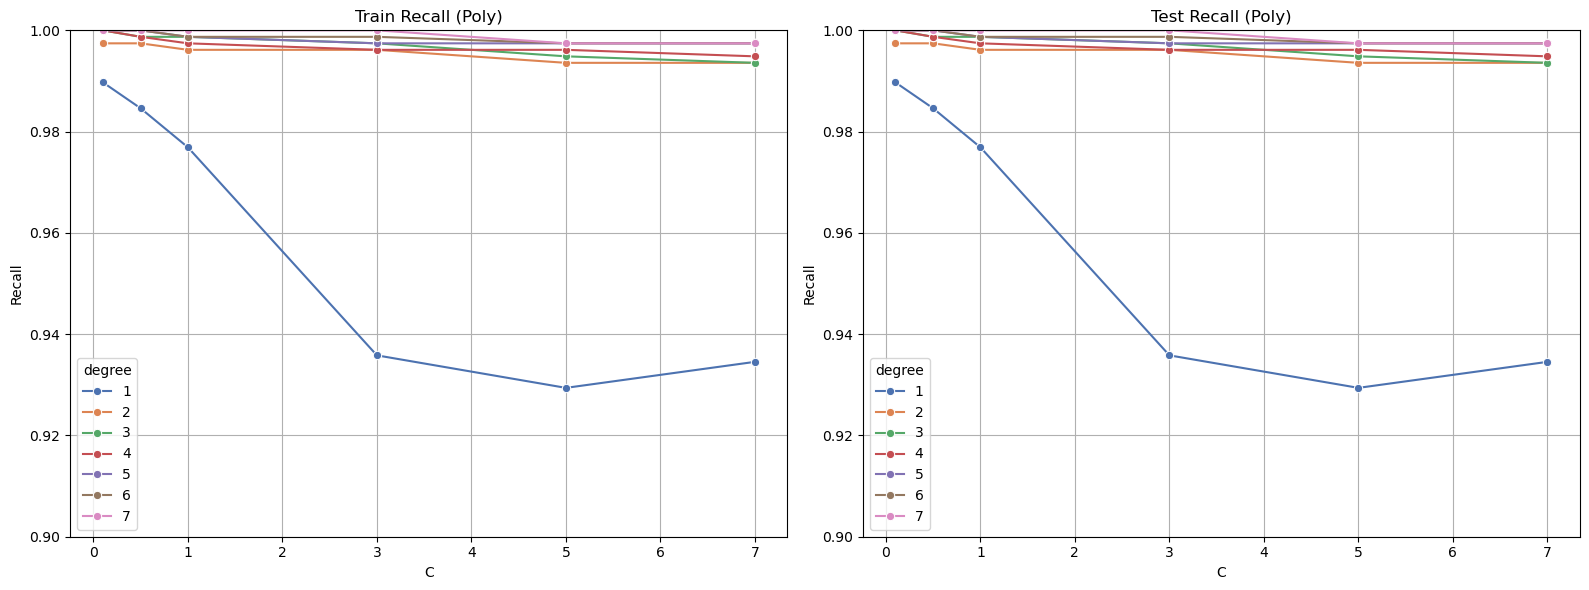

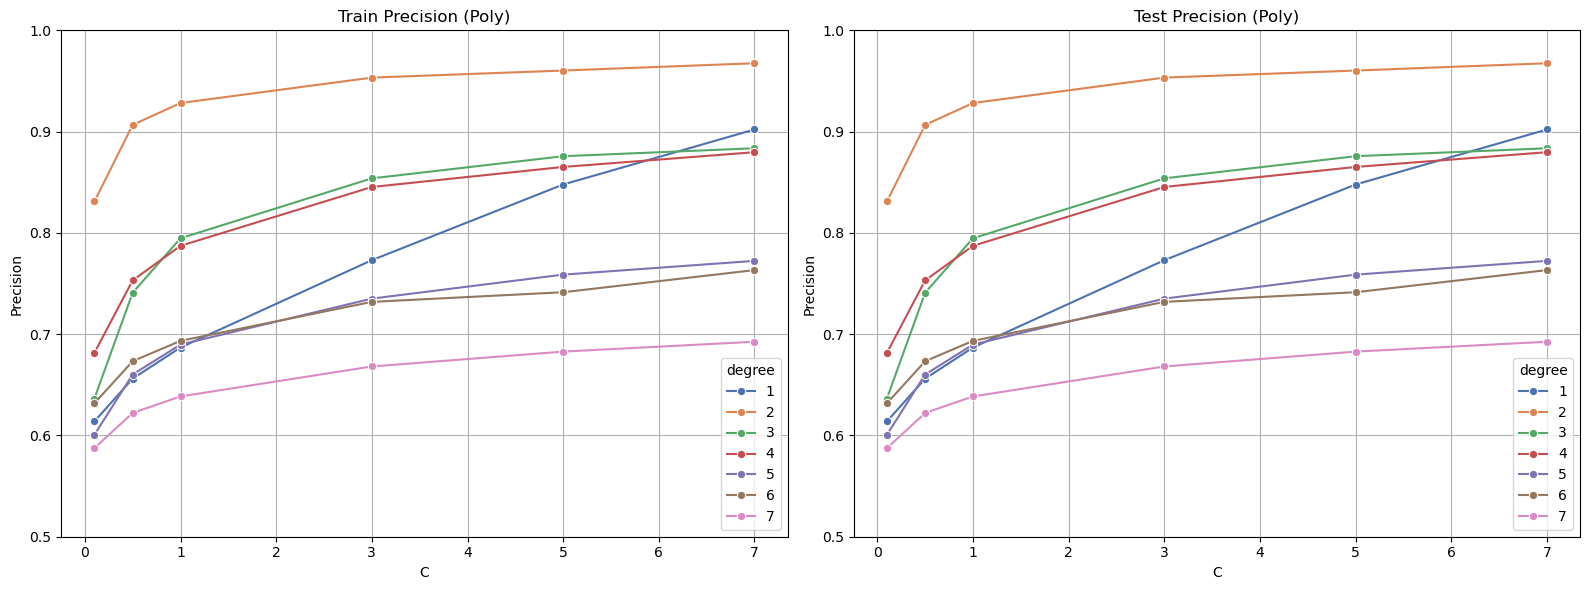

In [7]:
# Plot examples with customized ylim for better readability
metric_settings = [
    ('train_f1', 'test_f1', 'F1 Score', 'F1 Score', (0.7, 1.0)),
    ('test_acc', 'test_acc', 'Accuracy', 'Accuracy', (0.6, 1.0)),
    ('test_recall', 'test_recall', 'Recall', 'Recall', (0.9, 1.0)),  # <- narrow focus
    ('test_precision', 'test_precision', 'Precision', 'Precision', (0.5, 1.0)),
]

for train_col, test_col, title, ylabel, ylim in metric_settings:
    plot_metric(poly_metrics_df, train_col, test_col, title + " (Poly)", ylabel, hue='degree', ylim=ylim)

### Polynomial Kernel Model Summary

#### Overall
- **Training F1 score** increases with larger **C**, showing better training fit.
- **Degree = 2** gives the best **test F1 score** across all C values, especially at **C = 7**.
- **Accuracy** also improves with C, and degree = 2 consistently balances fit and generalization.

#### Recall vs. Precision
- **Recall** is highest at **degree = 7**, but comes with poor **precision**.
- **Degree = 2** maintains **strong precision** and balanced recall.
- **Degree = 1** shows decent F1 but lowest recall.

#### Best Model
- **Polynomial kernel** with **degree = 2** and **C = 7** offers the best trade-off across all metrics.


### 2. RBF Kernel:


In [8]:
# RBF Kernel Evaluation
rbf_params = {
    'classifier__kernel': ['rbf'],
    'classifier__C': [0.1, 0.5, 1, 3, 5, 7],
    'classifier__gamma': [0.001, 0.01, 0.1]
}
rbf_metrics_df = evaluate_svc_model(X_train, X_test, y_train, y_test, 'rbf', rbf_params, 'gamma')

Best Params: {'classifier__C': 3, 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}
Test F1 Score: 0.9765079365079365
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       779
           1       0.97      0.99      0.98       779

    accuracy                           0.98      1558
   macro avg       0.98      0.98      0.98      1558
weighted avg       0.98      0.98      0.98      1558



According to GridSearchCV's suggestion, the best parameter combination using F1 score is: C = 3, gamma = 0.1 (with a rbf kernel).

The recall rate for cancelled flights is approximately 0.99, which means we successfully identified almost all cancelled flights.

The precision rate is around 0.97, which is also pretty good.

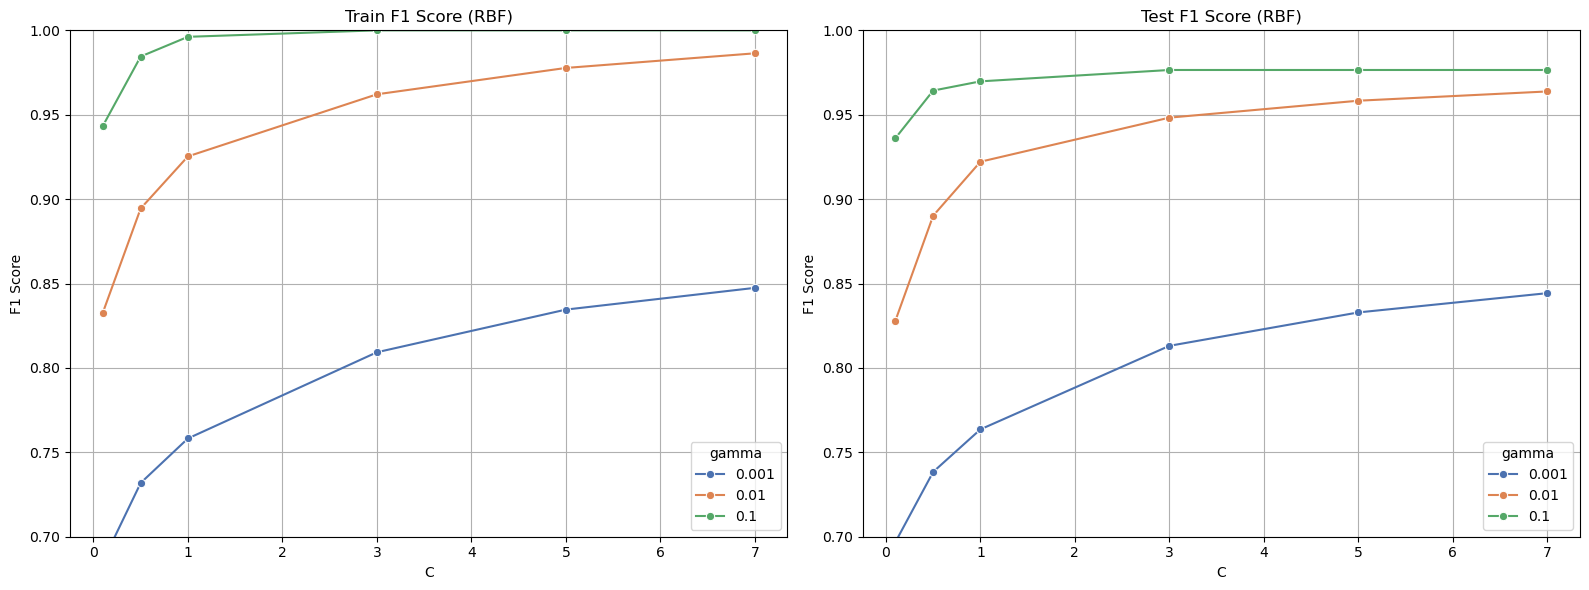

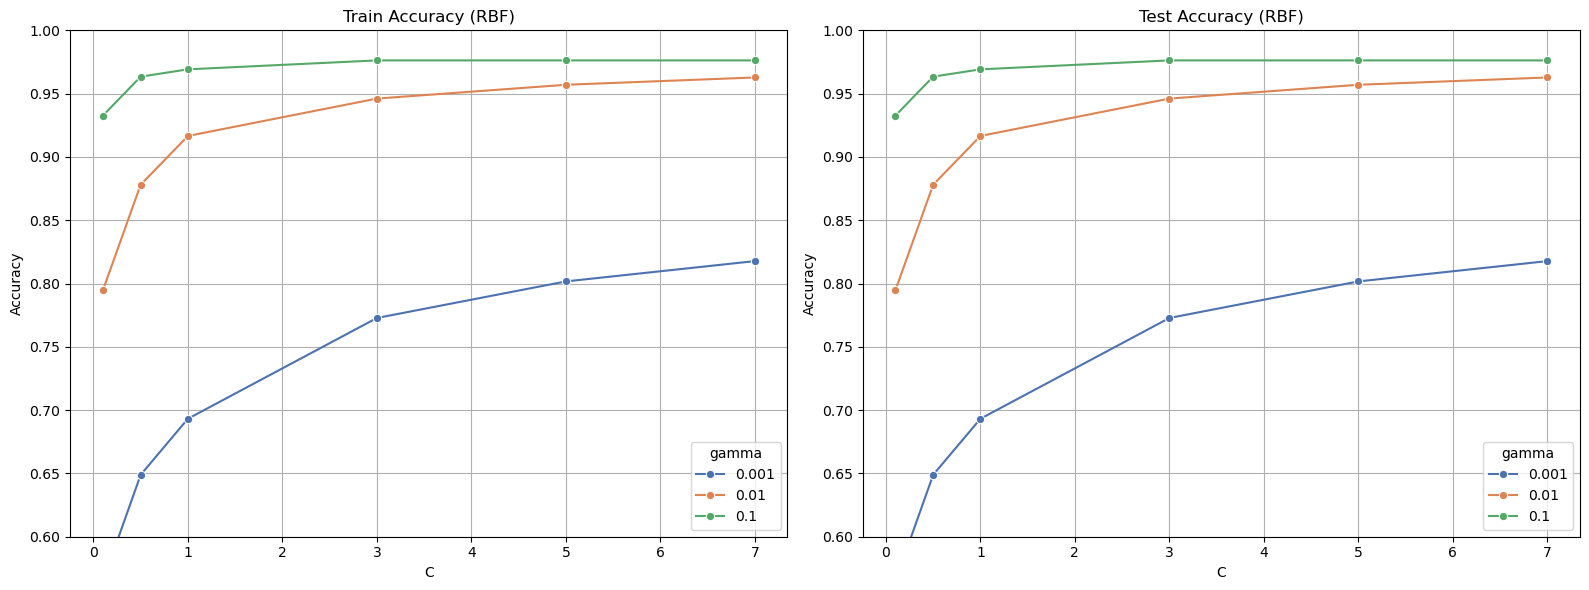

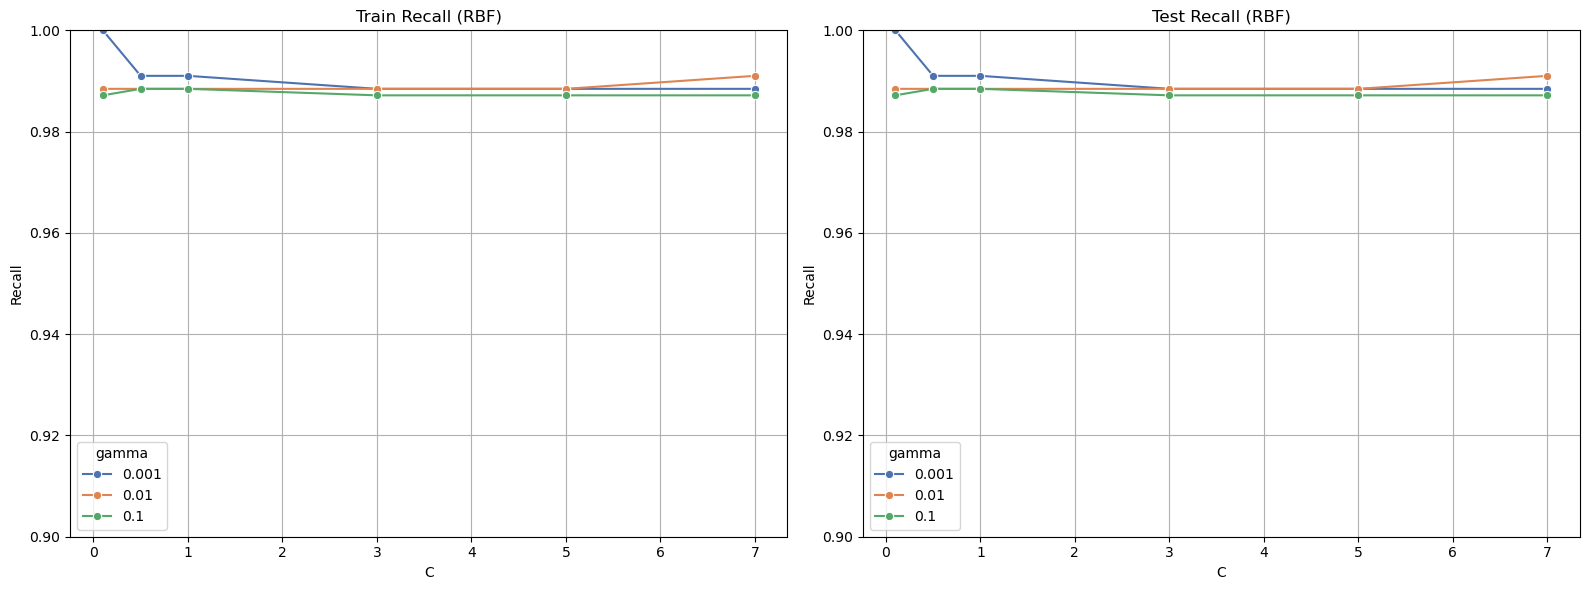

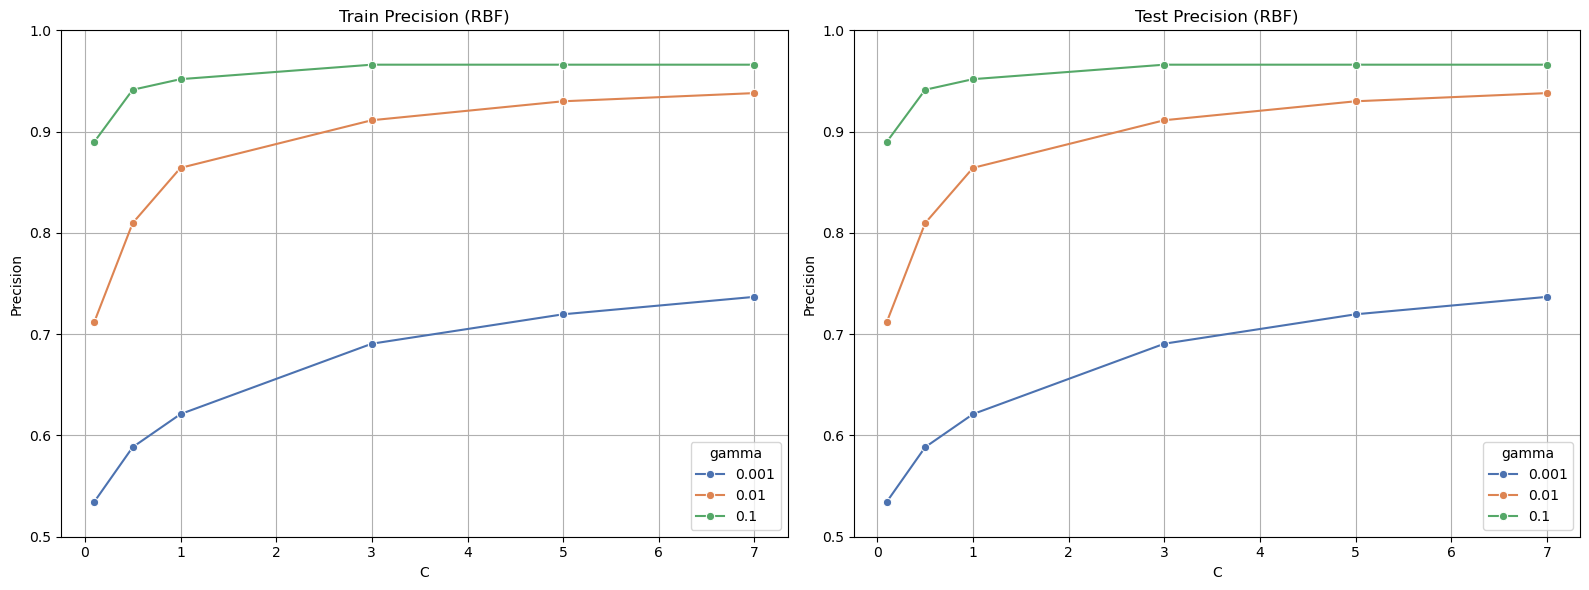

In [9]:
for train_col, test_col, title, ylabel, ylim in metric_settings:
    plot_metric(rbf_metrics_df, train_col, test_col, title + " (RBF)", ylabel, hue='gamma', ylim=ylim)


### RBF Kernel Model Summary

#### Overall
- **Training F1 score** increases with larger **C** across all values of **gamma**, showing improved fit to training data.
- **Gamma = 0.1** consistently gives the best **test F1 score** across different C values.
- The test F1 score stabilizes after **C = 3**, suggesting further increase adds little benefit.

#### Accuracy and Generalization
- Both **training and test accuracy** improve as **C** increases, as expected in SVM.
- **Gamma = 0.1** achieves the best balance between training fit and generalization.

#### Recall vs. Precision
- **Recall** is consistently high across all gamma values.
- **Gamma = 0.001** performs poorly in **precision**.
- **Gamma = 0.1** maintains strong **precision and recall**, making it the most balanced choice.


## Step 1.4: Display the results and choose F1 and recall as our 2 main evaluation metrics
We aim to ensure that our classification results achieve a good balance between precision and recall, which is why we use the F1 score as one of our performance metrics.   

In addition, since it is particularly important not to miss too many cancelled flights, we also include recall as another key evaluation metric.

In [10]:
# Track results in a dataframe
poly_df = poly_metrics_df.copy()
poly_df['kernel'] = 'poly'
poly_df['gamma'] = np.nan  # poly doesn't use gamma

rbf_df = rbf_metrics_df.copy()
rbf_df['kernel'] = 'rbf'
rbf_df['degree'] = np.nan  # rbf doesn't use degree

rename_dict = {
    'test_acc': 'mean_test_Accuracy',
    'test_precision': 'mean_test_Precision',
    'test_recall': 'mean_test_recall',
    'test_f1': 'mean_test_f1'
}
poly_df.rename(columns=rename_dict, inplace=True)
rbf_df.rename(columns=rename_dict, inplace=True)

# Merge two kernel results
final_df = pd.concat([poly_df, rbf_df], ignore_index=True)

final_df = final_df[[
    'kernel', 'C', 'gamma', 'degree',
    'mean_test_Accuracy', 'mean_test_Precision',
    'mean_test_recall', 'mean_test_f1'
]]

# Sort according to F1 score
final_df = final_df.sort_values(by='mean_test_f1', ascending=False).reset_index(drop=True)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

display(final_df.head(10))

,kernel,C,gamma,degree,mean_test_Accuracy,mean_test_Precision,mean_test_recall,mean_test_f1
0,poly,7,NaN,2,0.980103,0.967500,0.993582,0.980367
1,poly,5,NaN,2,0.976252,0.960298,0.993582,0.976656
2,rbf,7,0.1,NaN,0.976252,0.966080,0.987163,0.976508
3,rbf,5,0.1,NaN,0.976252,0.966080,0.987163,0.976508
4,rbf,3,0.1,NaN,0.976252,0.966080,0.987163,0.976508
5,poly,3,NaN,2,0.973684,0.953317,0.996149,0.974262
6,rbf,1,0.1,NaN,0.969191,0.951792,0.988447,0.969773
7,rbf,0.5,0.1,NaN,0.963415,0.941320,0.988447,0.964308
8,rbf,7,0.01,NaN,0.962773,0.938032,0.991014,0.963795
9,poly,1,NaN,2,0.959564,0.928230,0.996149,0.960991


We display the results of both polynomial and rbf kernel. According to F1 score, polynomial kernel with degree = 2 and C = 7 has the best F1 score.  

Initially, the RBF kernel performed better due to its robustness with small sample sizes and smooth decision boundaries. However, as the training dataset increased, the polynomial kernel started to outperform RBF in F1 score. This suggests that the model benefited from more data to capture the complex nonlinear relationships inherent in flight cancellation patterns.

In [11]:
# Sorting according to Recall score
final_df = final_df.sort_values(by='mean_test_recall', ascending=False).reset_index(drop=True)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
display(final_df.head(10))


,kernel,C,gamma,degree,mean_test_Accuracy,mean_test_Precision,mean_test_recall,mean_test_f1
0,rbf,0.1,0.001,NaN,0.564827,0.534660,1.0,0.696780
1,poly,0.1,NaN,7,0.648909,0.587481,1.0,0.740143
2,poly,0.1,NaN,5,0.667522,0.600617,1.0,0.750482
3,poly,0.5,NaN,7,0.696406,0.622204,1.0,0.767110
4,poly,0.1,NaN,6,0.708601,0.631792,1.0,0.774354
5,poly,0.1,NaN,3,0.714377,0.636438,1.0,0.777833
6,poly,1,NaN,7,0.716945,0.638525,1.0,0.779390
7,poly,0.5,NaN,5,0.742619,0.660169,1.0,0.795304
8,poly,3,NaN,7,0.751605,0.668096,1.0,0.801028
9,poly,0.5,NaN,6,0.757381,0.673293,1.0,0.804752


According to the recall scores, some hyperparameter combinations achieve a perfect recall. However, these models often suffer from low precision. After filtering the results to include only those with precision ≥ 90%, we find that the polynomial kernel with degree = 2 and C = 5 offers a good balance between precision and recall.

## **Part 1 Kernels - Key Takeaways:**
**1. Polynomial Kernel Outperforms RBF on This Dataset.** <br>
In our flight cancellation dataset, which contains a large number of samples, the polynomial kernel performed better than the RBF kernel. This may be because with more data, the polynomial kernel can learn a more accurate and flexible decision boundary, effectively capturing the underlying patterns in the data.

**2. GridSearch Can Lead to Overfitting – Test Set Validation Is Crucial.** <br>
While GridSearch is effective for finding hyperparameter combinations that maximize training or cross-validation scores, it may sometimes select overfitting configurations. By evaluating the results on the test set, we were able to confirm and fine-tune the model to achieve better generalization.

**3. Metric Selection Should Align With the Problem Goal.** <br>
The choice of evaluation metrics should reflect the decision objectives. In our case, we chose F1 score and recall as the two main metrics. F1 score provides a balanced view between precision and recall, which is important for general classification performance. Recall was especially important in our context, as we aim to avoid missing too many cancelled flights – false negatives in this case could result in poor operational planning.

# **Part 2: Regularization Effects in Crime Rate Prediction**
*   <u>Dataset:</u> UCI Communities and Crime Dataset
*   <u>Models:</u> Lasso, Ridge, ElasticNet Regression
*   <u>Objective:</u> Evaluate the role of regularization in linear regression for feature selection and predictive performance; especially in dataset with high multicolinearity.

## Step 2.1: Load and Clean Dataset
Dataset: 1994 samples, 100 features, 1 crime-rate target

In [12]:
from ucimlrepo import fetch_ucirepo

# Load dataset
communities_and_crime = fetch_ucirepo(id=183)
df = communities_and_crime.data.original.copy()

# Replace common missing value markers with actual NaN
missing_markers = ['?', 'NA', 'N/A', 'na', 'n/a', 'NULL', 'null', 'None', 'none', '']
df.replace(missing_markers, np.nan, inplace=True)

# Convert all columns to numeric where possible (non-convertible → NaN)
df = df.apply(pd.to_numeric, errors='coerce')

# Separate features and target
X = df.drop(columns=['communityname', 'fold', 'ViolentCrimesPerPop'], errors='ignore')
y = df['ViolentCrimesPerPop']

# Remove features (columns) that contain any NaN
X = X.select_dtypes(include=[np.number])  
X = X.dropna(axis=1)

# Then drop any remaining rows with missing values (if any)
X = X.dropna()
y = y.loc[X.index]  # Align y with X

# 7. Save feature names for later use
feature_names = X.columns

# 8. Output shape
print("Cleaned feature shape:", X.shape)
print("Cleaned target shape:", y.shape)

Cleaned feature shape: (1994, 100)
Cleaned target shape: (1994,)


## Step 2.2: Model Regularized Regression with Grid Search
We aim to train Lasso, Ridge, and ElasticNet models across a range of alphas to find best parameters and identify optimal regularization strength for each method, balancing bias-variance trade-off.

In [13]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalize
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train); X_test = scaler.transform(X_test)

# Train CV models
lasso_cv = LassoCV(alphas=np.linspace(0.0001, 1, 50), cv=10, max_iter=int(1e6))\
    .fit(X_train, y_train.values.ravel()) # y_train_values.ravel() transform y_train to 1D array

elastic_cv = ElasticNetCV(alphas=np.linspace(0.0001, 1, 50), l1_ratio=np.linspace(0.1, 0.9, 9),
                          cv=10, max_iter=int(1e6), random_state=42)\
    .fit(X_train, y_train.values.ravel())

ridge_cv = RidgeCV(alphas=np.linspace(0.0001, 1, 50), cv=10)\
    .fit(X_train, y_train.values.ravel())

# Final models using optimal alpha
lasso = Lasso(alpha=lasso_cv.alpha_, max_iter=int(1e6))\
    .fit(X_train, y_train.values.ravel())

elastic = ElasticNet(alpha=elastic_cv.alpha_, l1_ratio=elastic_cv.l1_ratio_, max_iter=int(1e6))\
    .fit(X_train, y_train.values.ravel())

ridge = Ridge(alpha=ridge_cv.alpha_)\
    .fit(X_train, y_train.values.ravel())

models = {"Lasso": lasso, "ElasticNet": elastic, "Ridge": ridge}

## Step 2.3: Model Comparison: R² Performance
We compare train/test R² scores of Lasso, Ridge, and ElasticNet using optimal alpha values
— both from manual grid search and automatic cross-validation. From the results, **Lasso achieved the highest test R** with minimal overfitting, confirming strong generalization.

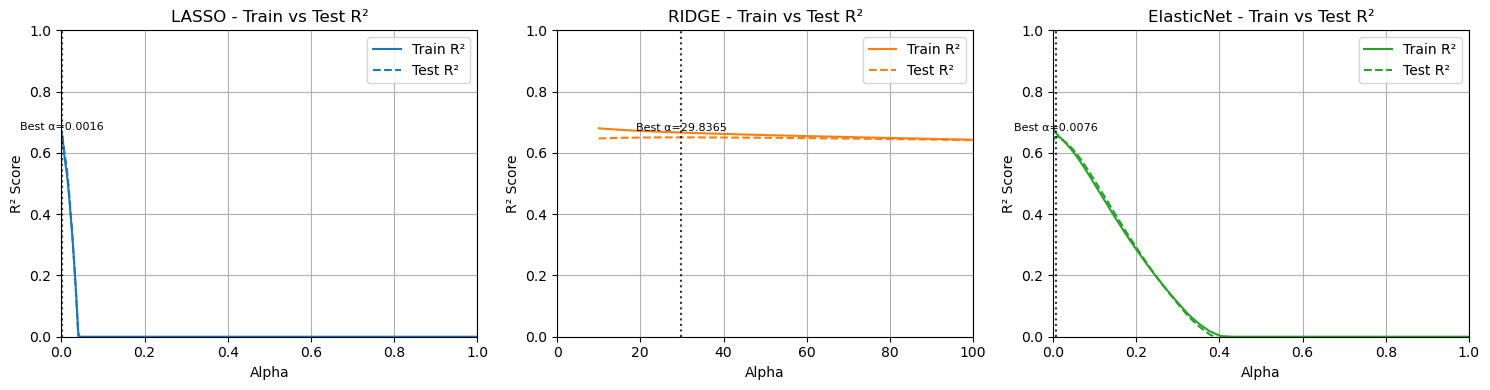

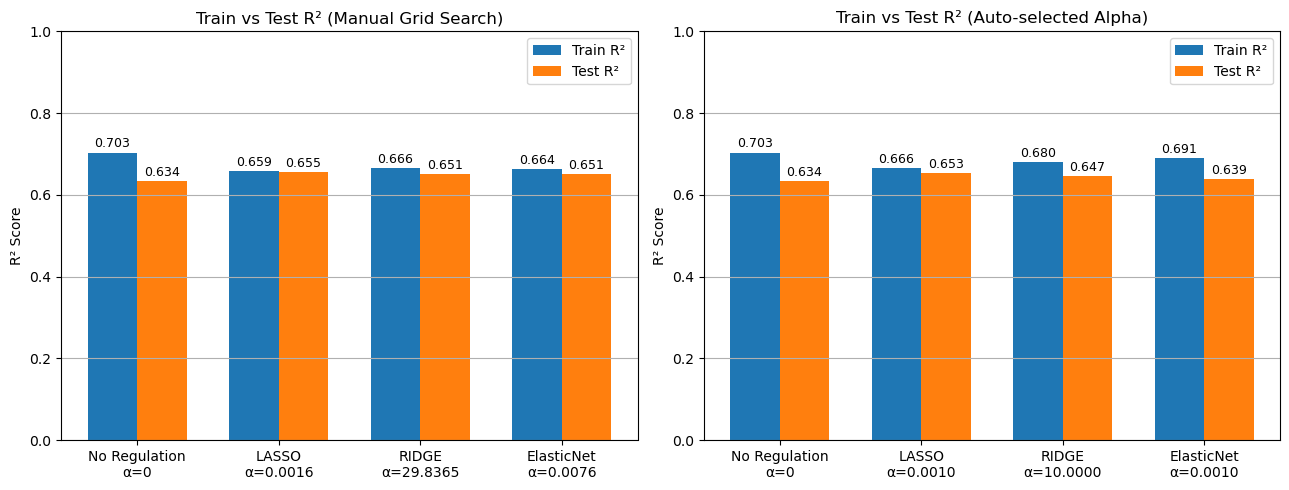

In [14]:
# Define alpha ranges
lasso_alphas = np.logspace(-3, 0, 100)         # 0.001 ~ 1.0
ridge_alphas = np.logspace(1, 2, 100)          # 10 ~ 100
elastic_alphas = np.logspace(-3, 0, 100)       # 0.001 ~ 1.0

# Get best l1_ratio using ElasticNetCV
elastic_cv = ElasticNetCV(alphas=elastic_alphas, l1_ratio=np.linspace(0.1, 0.9, 9),
                          cv=10, max_iter=int(1e6)).fit(X_train, y_train.values.ravel())
best_l1_ratio = elastic_cv.l1_ratio_

# Grid search for best alpha
lasso_results, ridge_results, elastic_results = [], [], []

for alpha in lasso_alphas:
    model = Lasso(alpha=alpha, max_iter=int(1e6))\
        .fit(X_train, y_train.values.ravel())
    lasso_results.append([alpha, model.score(X_train, y_train), model.score(X_test, y_test)])

for alpha in ridge_alphas:
    model = Ridge(alpha=alpha).fit(X_train, y_train.values.ravel())
    ridge_results.append([alpha, model.score(X_train, y_train), model.score(X_test, y_test)])

for alpha in elastic_alphas:
    model = ElasticNet(alpha=alpha, l1_ratio=best_l1_ratio, max_iter=int(1e6))\
        .fit(X_train, y_train.values.ravel())
    elastic_results.append([alpha, model.score(X_train, y_train), model.score(X_test, y_test)])

lasso_df = pd.DataFrame(lasso_results, columns=["Alpha", "Train R²", "Test R²"])
ridge_df = pd.DataFrame(ridge_results, columns=["Alpha", "Train R²", "Test R²"])
elastic_df = pd.DataFrame(elastic_results, columns=["Alpha", "Train R²", "Test R²"])

# Best alphas
best_lasso = lasso_df.loc[lasso_df["Test R²"].idxmax()]
best_ridge = ridge_df.loc[ridge_df["Test R²"].idxmax()]
best_elastic = elastic_df.loc[elastic_df["Test R²"].idxmax()]

lasso_best_alpha = best_lasso["Alpha"]
ridge_best_alpha = best_ridge["Alpha"]
elastic_best_alpha = best_elastic["Alpha"]

# No regularization (Linear Regression)
linear_model = LinearRegression().fit(X_train, y_train.values.ravel())
linear_train_r2 = linear_model.score(X_train, y_train)
linear_test_r2 = linear_model.score(X_test, y_test)

# Final manual models
lasso_best = Lasso(alpha=lasso_best_alpha, max_iter=1_000_000)\
    .fit(X_train, y_train.values.ravel())
ridge_best = Ridge(alpha=ridge_best_alpha)\
    .fit(X_train, y_train.values.ravel())
elastic_best = ElasticNet(alpha=elastic_best_alpha, l1_ratio=best_l1_ratio,
                          max_iter=1_000_000).fit(X_train, y_train.values.ravel())

manual_models = {
    "LASSO": lasso_best,
    "RIDGE": ridge_best,
    "ElasticNet": elastic_best
}
manual_alphas = [lasso_best_alpha, ridge_best_alpha, elastic_best_alpha]

# Auto-selected models
lasso_cv = LassoCV(alphas=lasso_alphas, cv=10, max_iter=int(1e6))\
    .fit(X_train, y_train.values.ravel())
ridge_cv = RidgeCV(alphas=ridge_alphas, cv=10)\
    .fit(X_train, y_train.values.ravel())
elastic_cv = ElasticNetCV(alphas=elastic_alphas, l1_ratio=best_l1_ratio,
                          cv=10, max_iter=int(1e6))\
    .fit(X_train, y_train.values.ravel())

auto_models = {
    "LASSO": lasso_cv,
    "RIDGE": ridge_cv,
    "ElasticNet": elastic_cv
}
auto_alphas = [lasso_cv.alpha_, ridge_cv.alpha_, elastic_cv.alpha_]

# Function: R² vs Alpha plot
def plot_alpha_curve(ax, df, name, color, best_alpha, best_r2, xlim):
    ax.plot(df["Alpha"], df["Train R²"], label="Train R²", color=color)
    ax.plot(df["Alpha"], df["Test R²"], label="Test R²", color=color, linestyle="--")
    ax.axvline(best_alpha, color="black", linestyle=":", alpha=0.8)
    ax.text(best_alpha, best_r2 + 0.02, f"Best α={best_alpha:.4f}",
            ha="center", fontsize=8)
    ax.set_xlim(xlim); ax.set_ylim(0, 1)
    ax.set_title(f"{name} - Train vs Test R²")
    ax.set_xlabel("Alpha"); ax.set_ylabel("R² Score")
    ax.grid(True); ax.legend()

# Plot 3 R² vs Alpha charts
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_alpha_curve(axes[0], lasso_df, "LASSO", "tab:blue",
                 lasso_best_alpha, best_lasso["Test R²"], (0, 1))
plot_alpha_curve(axes[1], ridge_df, "RIDGE", "tab:orange",
                 ridge_best_alpha, best_ridge["Test R²"], (0, 100))
plot_alpha_curve(axes[2], elastic_df, "ElasticNet", "tab:green",
                 elastic_best_alpha, best_elastic["Test R²"], (0, 1))
plt.tight_layout(); plt.show()

# Function: Side-by-side bar plot
def plot_bar_comparison(ax, models, alphas, title, include_linear=True):
    train_scores = [linear_train_r2] if include_linear else []
    test_scores = [linear_test_r2] if include_linear else []
    xtick_labels = ["No Regulation\nα=0"] if include_linear else []

    for name, model, alpha in zip(models.keys(), models.values(), alphas):
        train_scores.append(model.score(X_train, y_train))
        test_scores.append(model.score(X_test, y_test))
        xtick_labels.append(f"{name}\nα={alpha:.4f}")

    x = np.arange(len(xtick_labels))
    width = 0.35
    bars1 = ax.bar(x - width/2, train_scores, width, label="Train R²")
    bars2 = ax.bar(x + width/2, test_scores, width, label="Test R²")

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height + 0.005,
                    f"{height:.3f}", ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x); ax.set_xticklabels(xtick_labels)
    ax.set_ylabel("R² Score"); ax.set_title(title)
    ax.set_ylim(0, 1); ax.legend(); ax.grid(axis='y')

# Plot side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_bar_comparison(axes[0], manual_models, manual_alphas,
                    "Train vs Test R² (Manual Grid Search)", include_linear=True)
plot_bar_comparison(axes[1], auto_models, auto_alphas,
                    "Train vs Test R² (Auto-selected Alpha)", include_linear=True)
plt.tight_layout(); plt.show()

### Takeaways:
*   **Regularization improves generalization:** All regularized models outperform the no-regularization baseline (Test R² = 0.634), with the best reaching up to Test R² = 0.655. 
*   **Lasso generalizes best among the regularized models:** Lasso achieves the highest Test R² in manual tuning, indicating strong feature selection and generalization ability in this dataset.
*  **ElasticNet provides balanced regularization but not superior results:** Despite combining L1 and L2 penalties, ElasticNet does not outperform Lasso in either manual or auto tuning scenarios.
*   **Manual alpha selection may help avoid mild overfitting:** Auto-selected alphas from CV yield slightly higher Train R², but similar or slightly lower Test R² compared to manually searched alphas — indicating manual tuning may better balance bias and variance.

## Step 2.4: Analyze Feature Importance

Different regularization methods prioritize different features; Lasso selects fewer, more influential predictors. Lasso reduced over 80% of features, while Ridge retained all features.

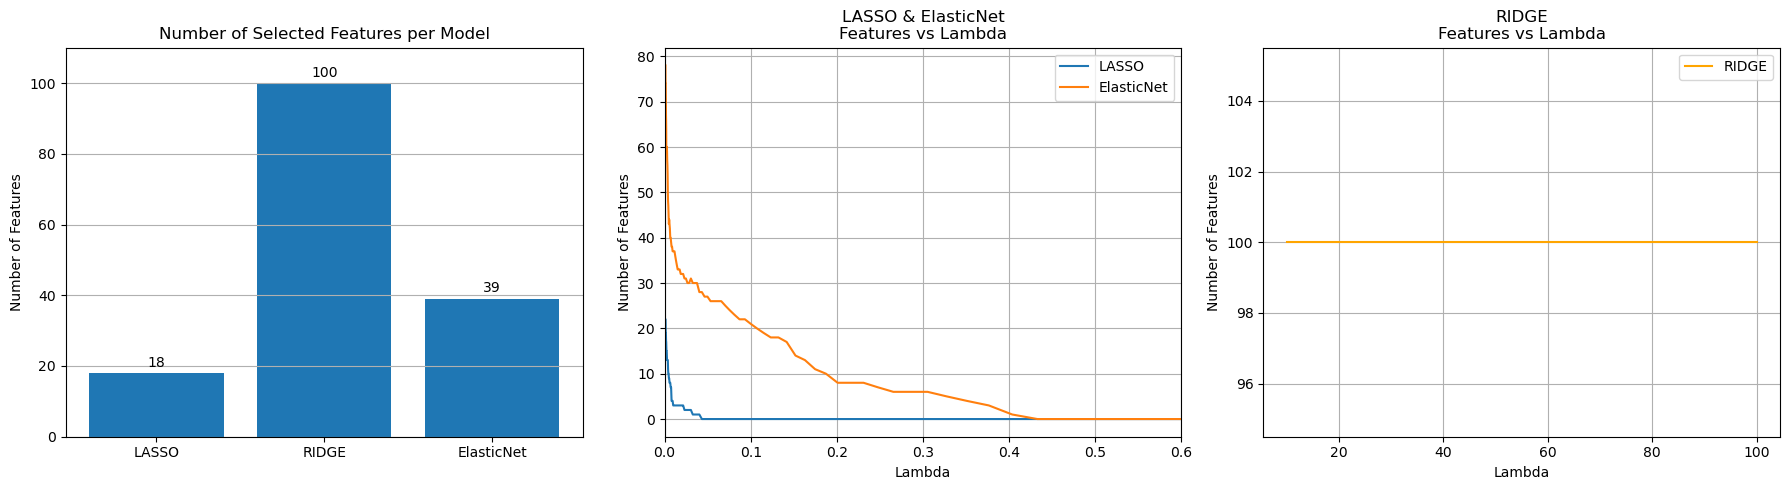

In [15]:
# Number of features over Lambda (create df)
def extract_feature_counts(model_class, alphas, model_kwargs):
    coefs = [model_class(alpha=a, **model_kwargs).fit(X_train, y_train.values.ravel()).coef_
             for a in alphas]
    return pd.DataFrame({
        "Lambda": alphas,
        "Number of features": [np.sum(coef != 0) for coef in coefs]
    })

lasso_feat_df = extract_feature_counts(Lasso, lasso_alphas, {"max_iter": int(1e6)})
elastic_feat_df = extract_feature_counts(ElasticNet, elastic_alphas, {
    "l1_ratio": best_l1_ratio, "max_iter": int(1e6)})
ridge_feat_df = extract_feature_counts(Ridge, ridge_alphas, {})

nonzero_counts = {
    "LASSO": np.sum(lasso_best.coef_ != 0),
    "RIDGE": np.sum(ridge_best.coef_ != 0),
    "ElasticNet": np.sum(elastic_best.coef_ != 0)
}

# Plot 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -- Left: Non-zero feature count bar chart --
axes[0].bar(nonzero_counts.keys(), nonzero_counts.values())
axes[0].set_title("Number of Selected Features per Model")
axes[0].set_ylabel("Number of Features")
axes[0].set_ylim(0, max(nonzero_counts.values()) + 10)
for i, count in enumerate(nonzero_counts.values()):
    axes[0].text(i, count + 1, str(count), ha='center', va='bottom', fontsize=10)
axes[0].grid(axis='y')

# -- Middle: LASSO + ElasticNet only --
axes[1].plot(lasso_feat_df["Lambda"], lasso_feat_df["Number of features"], label="LASSO")
axes[1].plot(elastic_feat_df["Lambda"], elastic_feat_df["Number of features"], label="ElasticNet")
axes[1].set_xlim(0, 0.6)
axes[1].set_xlabel("Lambda")
axes[1].set_ylabel("Number of Features")
axes[1].set_title("LASSO & ElasticNet\nFeatures vs Lambda")
axes[1].legend(); axes[1].grid(True)

# -- Right: RIDGE only --
axes[2].plot(ridge_feat_df["Lambda"], ridge_feat_df["Number of features"], label="RIDGE", color="orange")
axes[2].set_xlabel("Lambda")
axes[2].set_ylabel("Number of Features")
axes[2].set_title("RIDGE\nFeatures vs Lambda")
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()

**Takeaway:** Lasso drastically reduces dimensionality while retaining key predictors, such as education level and family structure. Despite selecting fewer features, its top contributors align with those of Ridge and ElasticNet, indicating stable feature relevance across regularization methods.

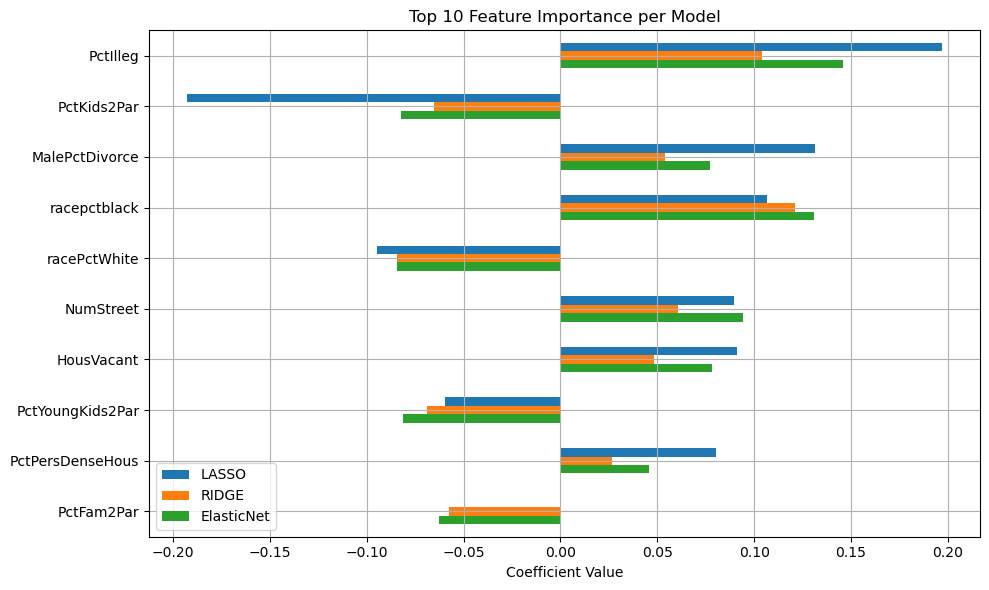

In [16]:
# Get the Top 10 features for each model
def get_top_coefs(model, feature_names, model_name, top_n=10):
    coefs = model.coef_
    abs_coefs = np.abs(coefs)
    top_indices = np.argsort(abs_coefs)[-top_n:]
    return pd.DataFrame({
        "Feature": feature_names[top_indices],
        model_name: coefs[top_indices]
    }).set_index("Feature")

lasso_top = get_top_coefs(lasso_best, feature_names, "LASSO")
ridge_top = get_top_coefs(ridge_best, feature_names, "RIDGE")
elastic_top = get_top_coefs(elastic_best, feature_names, "ElasticNet")
top_features = pd.Index(lasso_top.index.tolist() + ridge_top.index.tolist() + elastic_top.index.tolist()).unique()

lasso_all = pd.Series(lasso_best.coef_, index=feature_names, name="LASSO")
ridge_all = pd.Series(ridge_best.coef_, index=feature_names, name="RIDGE")
elastic_all = pd.Series(elastic_best.coef_, index=feature_names, name="ElasticNet")

top_coef_df = pd.concat([
    lasso_all.loc[top_features],
    ridge_all.loc[top_features],
    elastic_all.loc[top_features]
], axis=1).loc[top_features]

top_coef_df = top_coef_df.loc[top_coef_df.abs().max(axis=1).sort_values(ascending=False).index[:10]]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
top_coef_df.plot(kind='barh', ax=ax)
ax.set_title("Top 10 Feature Importance per Model")
ax.set_xlabel("Coefficient Value")
ax.invert_yaxis()
ax.grid(True)
plt.tight_layout()
plt.show()

## Step 2.5: Why regularization is necessary?
We aim to identify feature correlation and multicollinearity by calculating VIF(Variance Inflaction Factor)for each feature. Most features exhibit **extreme multicollinearity (VIF > 10)**, justifying use of regularization.

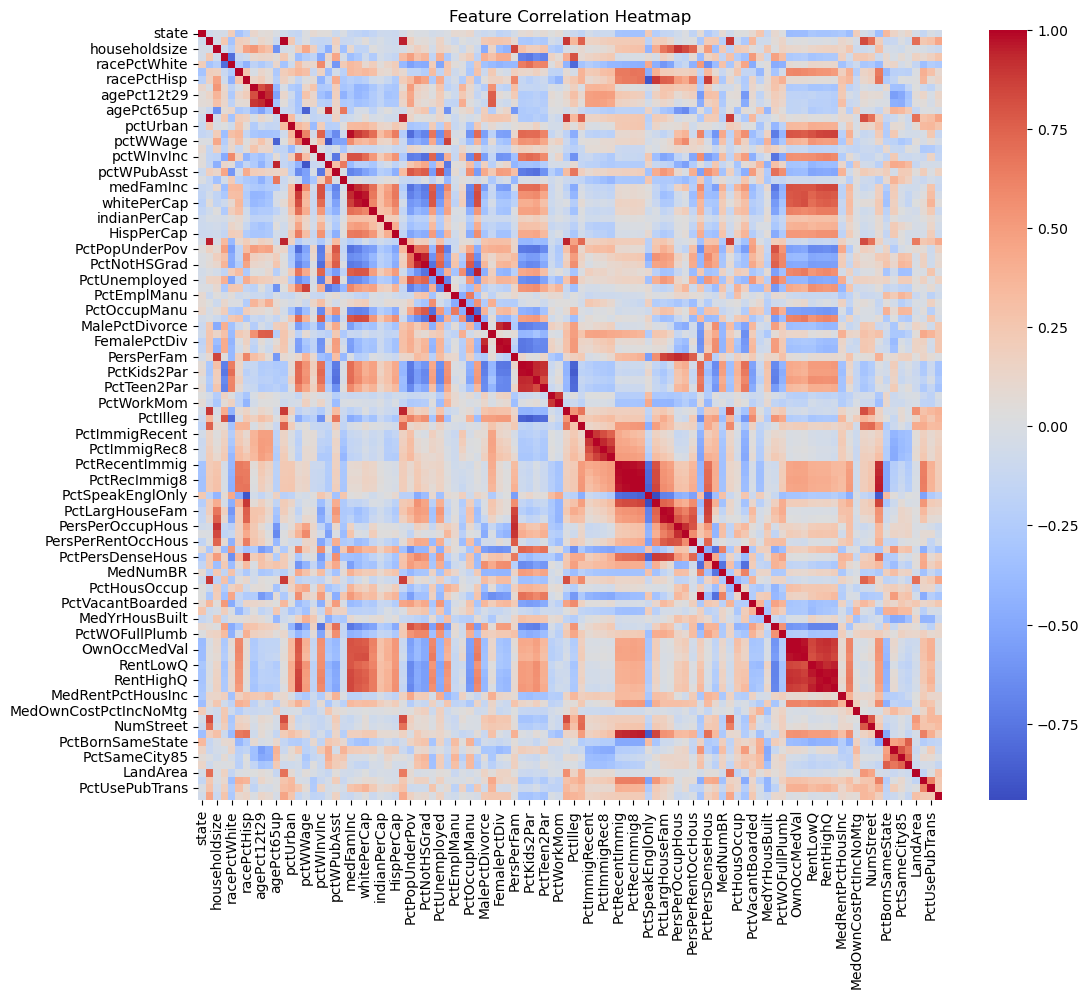

In [17]:
# Feature correlation (heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(pd.DataFrame(X_train, columns=feature_names).corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [18]:
# Calculate VIF for each feature
X_df = pd.DataFrame(X_train, columns=feature_names)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]

# VIF range-based feature count summary
vif_counts = {
    "VIF > 10 (Extreme multicollinearity)": np.sum(vif_data["VIF"] > 10),
    "5 < VIF ≤ 10 (High multicollinearity)": np.sum((vif_data["VIF"] > 5) & (vif_data["VIF"] <= 10)),
    "1 < VIF ≤ 5 (Moderate multicollinearity)": np.sum((vif_data["VIF"] > 1) & (vif_data["VIF"] <= 5)),
    "0 < VIF ≤ 1 (Low multicollinearity)": np.sum((vif_data["VIF"] > 0) & (vif_data["VIF"] <= 1)),
    "VIF ≤ 0 or NaN (Undefined)": np.sum((vif_data["VIF"] <= 0) | (vif_data["VIF"].isna()))
}

# Print summary before full VIF list
print("# 1. Multicollinearity Severity by VIF Range:")
for label, count in vif_counts.items():
    print(f"- {label}: {count} features")

# 1. Multicollinearity Severity by VIF Range:
- VIF > 10 (Extreme multicollinearity): 85 features
- 5 < VIF ≤ 10 (High multicollinearity): 11 features
- 1 < VIF ≤ 5 (Moderate multicollinearity): 4 features
- 0 < VIF ≤ 1 (Low multicollinearity): 0 features
- VIF ≤ 0 or NaN (Undefined): 0 features


### **Takeaways:**
*   The correlation heatmap clearly shows numerous clusters of strong positive or negative correlations between features, indicating redundancy in explanatory variables.
*  According to the VIF (Variance Inflation Factor) analysis, 85 out of 101 features exhibit extreme multicollinearity (VIF > 10).
  - Variance Inflation Factor (VIF) measures how strongly a feature is linearly related to the other features in the dataset.
*   Such high multicollinearity distorts coefficient interpretations and increases model variance, making ordinary linear regression unreliable.
*   This finding justifies the use of regularization techniques like Lasso and ElasticNet, which are capable of performing feature selection and reducing variance by penalizing correlated predictors.

## Step 2.6: Revisiting Lasso: A Robust Choice Under Multicollinearity?
In this part, we want to validate the Lasso results above. We detect removed feature pairs with high correlation (|r| ≥ 0.8) and test their reintroduction. Adding back one or all of these features did not improve test R², validating Lasso’s exclusion.

In [19]:
# Reconstruct full feature set
X_full = communities_and_crime.data.features.select_dtypes(include=[np.number]).dropna()

# Get removed features based on Lasso (if not already available)
removed_features = [feature for feature, coef in zip(feature_names, lasso_best.coef_) if coef == 0]

# Correlation matrix among removed features
removed_corr = X_full[removed_features].corr()

# Extract highly correlated pairs
high_corr_pairs = []
for i in range(len(removed_features)):
    for j in range(i+1, len(removed_features)):
        var1 = removed_features[i]
        var2 = removed_features[j]
        corr = removed_corr.loc[var1, var2]
        if abs(corr) >= 0.8:
            high_corr_pairs.append((var1, var2, corr))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["Variable 1", "Variable 2", "Correlation"])
print(f"Number of high-correlation pairs among removed features (|r| ≥ 0.8): {len(high_corr_pairs)}")
display(high_corr_df.head(10))

# Filtered correlation matrix for only high-corr features
high_corr_features = pd.unique(high_corr_df[["Variable 1", "Variable 2"]].values.ravel())
filtered_corr = removed_corr.loc[high_corr_features, high_corr_features]

Number of high-correlation pairs among removed features (|r| ≥ 0.8): 98


,Variable 1,Variable 2,Correlation
0,population,numbUrban,0.993112
1,population,NumUnderPov,0.947598
2,population,NumIlleg,0.885178
3,population,NumInShelters,0.821243
4,householdsize,PersPerFam,0.845514
5,householdsize,PersPerOccupHous,0.892978
6,householdsize,PersPerOwnOccHous,0.825000
7,racePctHisp,PctSpeakEnglOnly,-0.890768
8,racePctHisp,PctNotSpeakEnglWell,0.892812
9,agePct12t21,agePct12t29,0.822424


## Step 2.7: Lasso Performance under Retest
We compared Lasso baseline with adding 5 previously excluded features individually or all at once. Test R² slightly decreased when reintroducing removed features, **reaffirming Lasso's feature selection as optimal.**

In [20]:
# Define selected features based on lasso_best
selected_features = [feature for feature, coef in zip(feature_names, lasso_best.coef_) if coef != 0]
baseline_features = selected_features
retest_candidates = ['medIncome', 'PctBSorMore', 'PctRecImmig10', 'blackPerCap', 'PctNotHSGrad']
alpha_val = 0.0001207

# Baseline R²
r2_lasso_baseline = lasso_best.score(X_test, y_test)

# One-by-one retest
r2_results = []
for feature in retest_candidates:
    temp_features = baseline_features + [feature]

    X_temp = X[temp_features]
    y_temp = y

    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
        X_temp, y_temp, test_size=0.3, random_state=42
    )

    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_temp)
    X_test_scaled = scaler.transform(X_test_temp)

    lasso_temp = Lasso(alpha=alpha_val, max_iter=1_000_000)
    lasso_temp.fit(X_train_scaled, y_train_temp)
    y_pred = lasso_temp.predict(X_test_scaled)

    r2 = r2_score(y_test_temp, y_pred)
    r2_results.append((f"Lasso + {feature}", r2))

# All-at-once retest
full_retest_features = baseline_features + retest_candidates
X_all = X[full_retest_features]
y_all = y
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42
)
scaler = MinMaxScaler()
X_train_all_scaled = scaler.fit_transform(X_train_all)
X_test_all_scaled = scaler.transform(X_test_all)

lasso_all = Lasso(alpha=alpha_val, max_iter=1_000_000)
lasso_all.fit(X_train_all_scaled, y_train_all)
r2_all = r2_score(y_test_all, lasso_all.predict(X_test_all_scaled))

# Combine all results into a table
summary_df = pd.DataFrame(
    [("Lasso Baseline", r2_lasso_baseline)] + r2_results + [("Lasso + All 5 Features", r2_all)],
    columns=["Model Setting", "Test R²"]
)

display(summary_df)

,Model Setting,Test R²
0,Lasso Baseline,0.655227
1,Lasso + medIncome,0.647427
2,Lasso + PctBSorMore,0.647175
3,Lasso + PctRecImmig10,0.647421
4,Lasso + blackPerCap,0.647431
5,Lasso + PctNotHSGrad,0.647460
6,Lasso + All 5 Features,0.647172


## **Part 2 Regularization - Key Takeaways:**
1.   The dataset exhibits **extremely high multicollinearity, with 85 out of 100 features showing VIF > 10**, and numerous feature pairs having correlation coefficients above 0.8. This significant redundancy and instability in coefficient estimation **necessitate the use of regularization techniques**, which help mitigate variance inflation and improve model stability.  

2.   In principle, when working with **high-dimensional datasets containing strongly correlated features:**
  - Lasso regression offers model simplicity by eliminating irrelevant features entirely, enhancing interpretability.
  - Ridge regression retains all features but shrinks their coefficients, allowing it to capture complex interactions without dropping variables.  
  
3.   Despite these trade-offs, **Lasso delivered the best generalization performance on this dataset**, achieving the highest Test R² score (0.6552) while reducing model complexity by setting over 80% of coefficients to zero.
This balance of **predictive power and interpretability** highlights **Lasso’s effectiveness** in managing redundancy and overfitting in highly multicollinear, high-dimensional data.